# Extracción Topológica: Grafo de Cabárceno

En este notebook realizaremos la fase de **Ingeniería de Datos Espaciales**. Nuestro objetivo es conectarnos a la API de Overpass de OpenStreetMap (OSM) para descargar la red de carreteras internas del Parque de la Naturaleza de Cabárceno.

Matemáticamente, estamos construyendo un grafo dirigido $G = (V, E)$, donde:
* **V (Vértices/Nodos):** Son las intersecciones de los caminos.
* **E (Aristas/Edges):** Son los tramos de carretera. El peso de cada arista $c_{ij}$ será la distancia real en metros.

In [4]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import matplotlib.pyplot as plt
import os

# Configurar OSMnx para que imprima logs útiles en consola
ox.settings.log_console = True
ox.settings.use_cache = True
ox.settings.cache_folder = os.path.join(os.path.expanduser("~"), ".cache", "osmnx")

## 1. Descarga del Grafo de OSM

Usaremos una query espacial. Cabárceno es un recinto cerrado, por lo que algunas de sus vías internas podrían estar etiquetadas en OSM como vías de servicio o privadas. Por ello, usaremos un filtro personalizado para asegurarnos de capturar los caminos por los que circulan los coches de los visitantes.

Descargando el grafo para: Parque de la Naturaleza de Cabárceno, Cantabria, Spain...
Grafo descargado. Nodos: 295, Aristas: 545


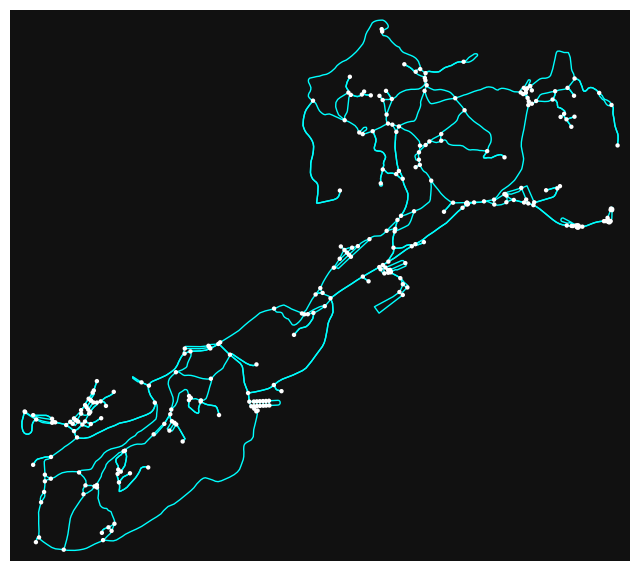

In [5]:
# Definimos el área de búsqueda
place_name = "Parque de la Naturaleza de Cabárceno, Cantabria, Spain"

# Filtro para coger carreteras por las que puede ir un coche (incluyendo vías de servicio internas del parque)
custom_filter = '["highway"~"primary|secondary|tertiary|residential|unclassified|service"]'

print(f"Descargando el grafo para: {place_name}...")
G_raw = ox.graph_from_place(
    place_name, 
    network_type='drive', # Red transitable por coches
    custom_filter=custom_filter,
    simplify=True         # Simplifica la topología eliminando nodos intermedios innecesarios
)

print(f"Grafo descargado. Nodos: {len(G_raw.nodes)}, Aristas: {len(G_raw.edges)}")

# Visualización rápida del grafo extraído
fig, ax = ox.plot_graph(G_raw, node_size=10, edge_linewidth=1, bgcolor='#111111', edge_color='cyan')

## 2. Proyección Matemática (CRS)

El grafo original viene en coordenadas esféricas WGS84 (Latitud/Longitud). Para poder aplicar algoritmos de optimización (TSP/VRP) necesitamos calcular las métricas $c_{ij}$ en **metros reales**, no en grados decimales. 

Vamos a proyectar el grafo a un plano cartesiano 2D utilizando el sistema UTM (Universal Transverse Mercator). OSMnx detectará automáticamente la zona UTM de Cantabria (Zona 30N).

In [7]:
# Proyectar el grafo a coordenadas UTM (en metros)
G_proj = ox.project_graph(G_raw)

# Comprobamos los sistemas de coordenadas
print("CRS original (Grados):", G_raw.graph['crs'])
print("CRS proyectado (Metros):", G_proj.graph['crs'])

CRS original (Grados): epsg:4326
CRS proyectado (Metros): EPSG:32630


## 3. Exportación de Artefactos

Para mantener el pipeline limpio, guardaremos el grafo matemático proyectado en formato `GraphML` (el estándar para teoría de grafos). También lo exportaremos como GeoDataFrames para poder cargarlos más adelante en nuestra aplicación interactiva si queremos pintar polígonos o hacer análisis rápido.

In [9]:
import pathlib

# El workspace está en un VFS de sólo lectura, así que guardamos localmente
OUTPUT_DIR = pathlib.Path.home() / "cabarceno-data" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 1. Guardar el grafo matemático completo para el motor de optimización (OR-Tools)
filepath_graphml = OUTPUT_DIR / "cabarceno_graph.graphml"
ox.save_graphml(G_proj, filepath=str(filepath_graphml))
print(f"Grafo guardado exitosamente en: {filepath_graphml}")

# 2. Guardar nodos y aristas como GeoDataFrames y GeoJSON para visualización web
nodes, edges = ox.graph_to_gdfs(G_proj)

filepath_nodes = OUTPUT_DIR / "cabarceno_nodes.geojson"
filepath_edges = OUTPUT_DIR / "cabarceno_edges.geojson"

# Eliminamos columnas complejas (listas) que GeoJSON no soporta bien al exportar
cols_to_drop_edges = [col for col in edges.columns if type(edges[col].iloc[0]) == list]
edges_clean = edges.drop(columns=cols_to_drop_edges)

nodes.to_file(str(filepath_nodes), driver='GeoJSON')
edges_clean.to_file(str(filepath_edges), driver='GeoJSON')

print("GeoDataFrames exportados a GeoJSON listos para Streamlit y Folium.")

Grafo guardado exitosamente en: /Users/david/cabarceno-data/processed/cabarceno_graph.graphml
GeoDataFrames exportados a GeoJSON listos para Streamlit y Folium.
